# Machine Learning Assignment Notebook
## Breast Cancer Classification using Four Supervised Learning Algorithms

**Algorithms used**
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbors (KNN)

**Goal**  
Build and compare four supervised machine learning models to predict whether a breast cancer tumor is **malignant** or **benign**.

**Dataset note**  
This notebook uses the Breast Cancer Wisconsin dataset obtained from a publicly available source on Kaggle. The dataset is based on the well-known Wisconsin Diagnostic Breast Cancer dataset and contains features computed from digitized images of breast mass cell nuclei. The dataset was downloaded as a CSV file and used for model training and evaluation.




In [ ]:
# Imports
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

pd.set_option("display.max_columns", None)


## 1. Load the Dataset

In [ ]:
#load the dataset
df = pd.read_csv("data.csv")

if "id" in df.columns:
    df = df.drop("id", axis=1)

if "Unnamed: 32" in df.columns:
    df = df.drop("Unnamed: 32", axis=1)

df["target"] = df["diagnosis"].map({"M": 0, "B": 1})

df["diagnosis_label"] = df["target"].map({0: "malignant", 1: "benign"})

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (569, 33)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,target,diagnosis_label
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


## 2. Dataset Description
The dataset contains numeric features computed from digitized images of breast mass cell nuclei.  
The target variable is:

- **0 = malignant**
- **1 = benign**

Now let's inspect the dataset structure.


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-null

In [4]:
df.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
texture_mean,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
area_mean,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
compactness_mean,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
concavity_mean,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
concave points_mean,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


## 3. Check Missing Values

In [5]:
df.isnull().sum().sort_values(ascending=False).head(10)

Unnamed: 32            569
diagnosis                0
radius_mean              0
texture_mean             0
area_mean                0
perimeter_mean           0
compactness_mean         0
concavity_mean           0
concave points_mean      0
smoothness_mean          0
dtype: int64

## 4. Class Distribution

In [6]:
class_counts = df["diagnosis"].value_counts()
class_counts


diagnosis
B    357
M    212
Name: count, dtype: int64

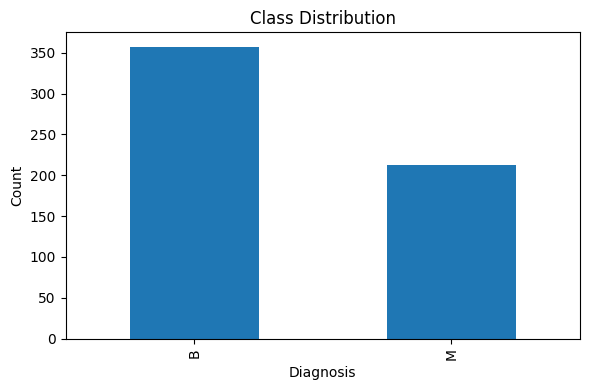

In [7]:
plt.figure(figsize=(6,4))
class_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## 5. Feature Matrix and Target Vector

In [16]:
X = df.drop(columns=["target", "diagnosis", "diagnosis_label"])
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


## 6. Train-Test Split
We split the data into:
- **80% training**
- **20% testing**


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 455
Testing samples: 114


## 7. Model Definitions
We use four supervised classification algorithms:
- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors


In [18]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),

    "Decision Tree": Pipeline([
        ("model", DecisionTreeClassifier(random_state=42, max_depth=5))
    ]),

    "Random Forest": Pipeline([
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            max_depth=8
        ))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ])
}

list(models.keys())


['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN']

## 8. Train and Evaluate Models
We evaluate each model using:
- Accuracy
- Precision
- Recall
- F1-score


In [19]:
results = []

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    results.append({
        "Algorithm": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
results_df


,Algorithm,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
1,Random Forest,0.956140,0.958904,0.972222,0.965517
2,KNN,0.956140,0.958904,0.972222,0.965517
3,Decision Tree,0.921053,0.956522,0.916667,0.936170


In [20]:
# Show rounded values for report use
results_df_rounded = results_df.copy()
for col in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    results_df_rounded[col] = results_df_rounded[col].round(4)

results_df_rounded


,Algorithm,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.9825,0.9861,0.9861,0.9861
1,Random Forest,0.9561,0.9589,0.9722,0.9655
2,KNN,0.9561,0.9589,0.9722,0.9655
3,Decision Tree,0.9211,0.9565,0.9167,0.9362


## 9. Accuracy Comparison Chart

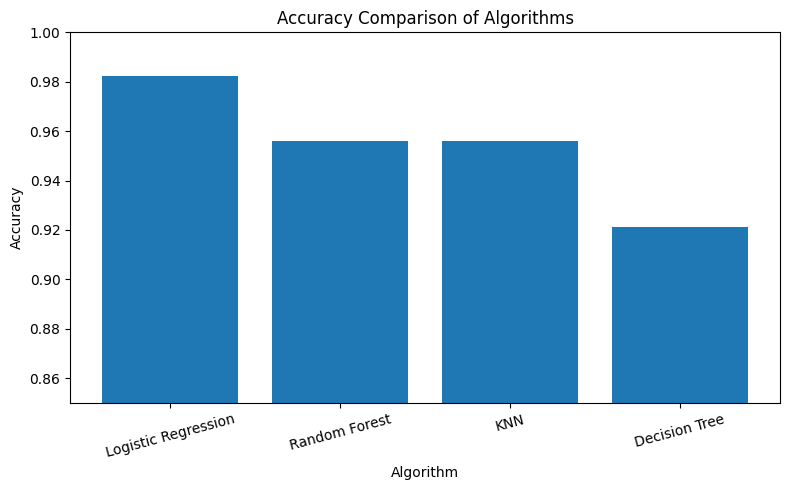

In [21]:
plt.figure(figsize=(8,5))
plt.bar(results_df_rounded["Algorithm"], results_df_rounded["Accuracy"])
plt.title("Accuracy Comparison of Algorithms")
plt.xlabel("Algorithm")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.ylim(0.85, 1.0)
plt.tight_layout()
plt.show()


## 10. Detailed Classification Reports

In [22]:
for name, pipeline in models.items():
    y_pred = pipeline.predict(X_test)
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(classification_report(y_test, y_pred, target_names=["malignant", "benign"]))
    print()


Logistic Regression
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Decision Tree
              precision    recall  f1-score   support

   malignant       0.87      0.93      0.90        42
      benign       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114


Random Forest
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96 

## 11. Confusion Matrices

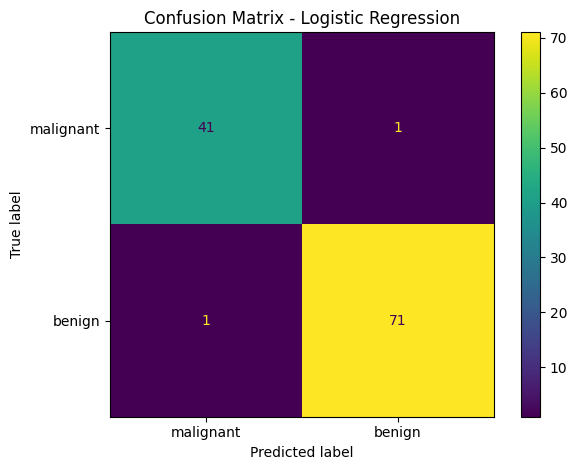

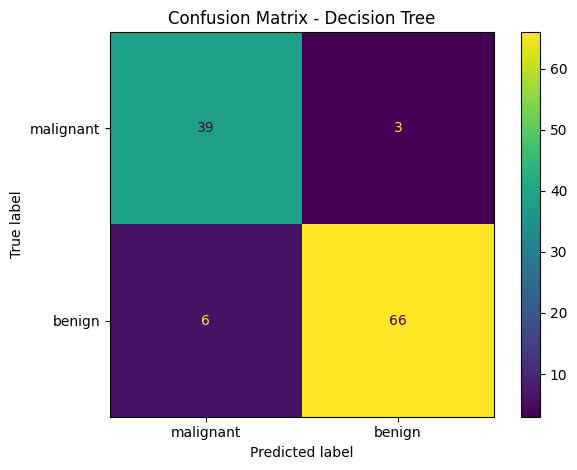

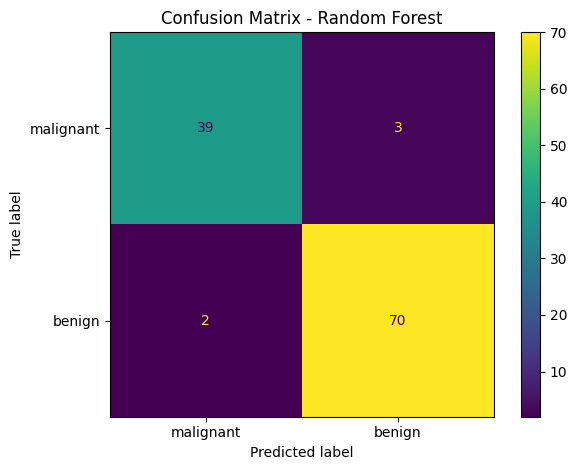

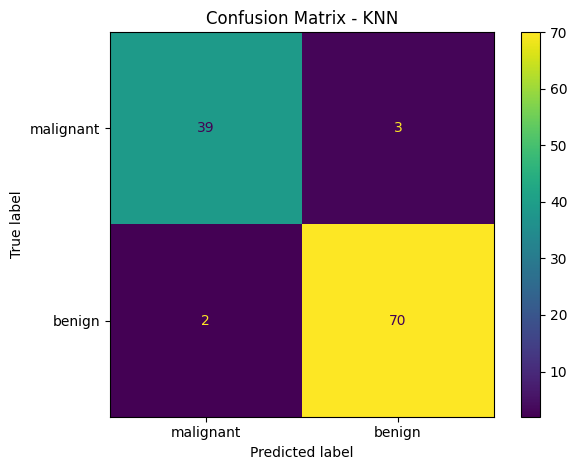

In [23]:
for name, pipeline in models.items():
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["malignant", "benign"])
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()


## 12. Feature Importance (Random Forest)
This helps explain which features influenced predictions the most.


In [24]:
rf_model = models["Random Forest"].named_steps["model"]
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importances.head(10)


,Feature,Importance
22,perimeter_worst,0.133636
23,area_worst,0.126589
27,concave points_worst,0.106882
7,concave points_mean,0.095657
20,radius_worst,0.091010
0,radius_mean,0.058910
2,perimeter_mean,0.054875
3,area_mean,0.050474
6,concavity_mean,0.045537
26,concavity_worst,0.036773


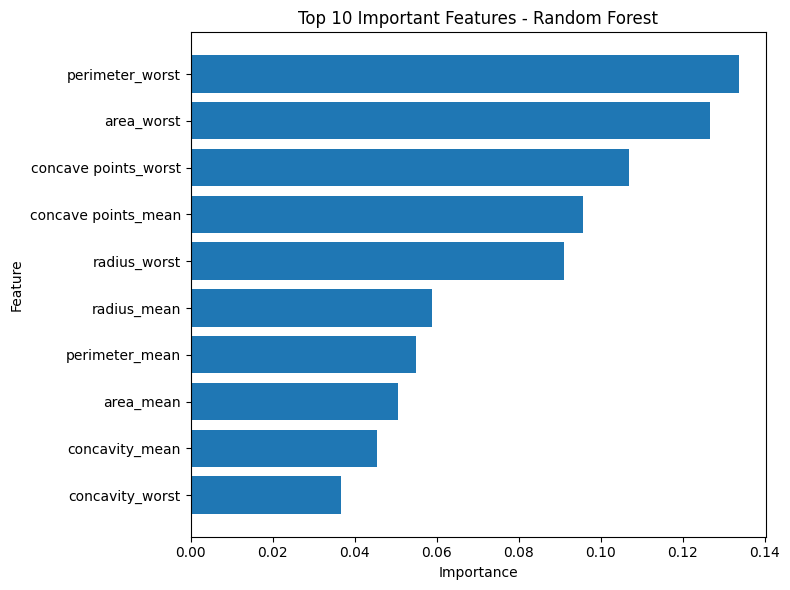

In [25]:
top10 = importances.head(10).sort_values(by="Importance")

plt.figure(figsize=(8,6))
plt.barh(top10["Feature"], top10["Importance"])
plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 13. Final Discussion
Use the generated results table to discuss:

- Which algorithm performed best
- Why some models performed better than others
- Possible limitations
- Future improvements

You can usually say:
- Random Forest often performs very well because it combines many decision trees and reduces overfitting.
- Logistic Regression is simpler and interpretable.
- KNN can perform well after scaling but may be sensitive to the choice of `k`.
- Decision Tree is easy to understand but may overfit if not controlled.

You should compare models using the actual values generated in your notebook.


## 14. Save Results for Report

In [26]:
results_df_rounded.to_csv("model_results.csv", index=False)
importances.to_csv("random_forest_feature_importance.csv", index=False)

print("Saved:")
print("- model_results.csv")
print("- random_forest_feature_importance.csv")


Saved:
- model_results.csv
- random_forest_feature_importance.csv


## 15. Simple Conclusion
This notebook demonstrated a supervised learning approach for classifying breast cancer cases using four machine learning algorithms.  
After preprocessing, training, and testing, the models were compared using standard classification metrics such as accuracy, precision, recall, and F1-score.  
The best-performing model can be identified from the results table and discussed in the final report.
